In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("flats_transformed.csv")

In [3]:
data["is_big_city_binary"] = data["is_big_city"].astype(int)
data["price_per_sqm"] = data["price"] / data["area"]

In [4]:
Kyiv_flats = data[data["city"] == "Kyiv"]

X_Kyiv = Kyiv_flats.drop(columns=["price", "city", "old_building", "close_to_BL", "close_to_borders", "popular_tourist_city", "is_big_city", "floor_class", "price_per_sqm", "region", "is_big_city_binary"])
y_Kyiv = Kyiv_flats["price_per_sqm"]

X_Kyiv

,num_of_rooms,area,living_area,kitchen_area,floor,floors_in_house,year_of_building
784,3,93.0,49.0,25.0,6,9,1970
785,3,93.0,68.0,12.0,5,5,2012
786,2,81.0,31.0,21.0,21,31,2017
787,2,50.2,26.8,6.0,3,9,1972
788,1,43.0,23.0,11.0,6,24,2023
...,...,...,...,...,...,...,...
4011,1,32.0,0.0,8.0,7,9,1990
4012,1,39.0,0.0,14.0,5,9,2021
4013,2,89.0,0.0,30.0,24,24,2018
4014,2,67.0,0.0,10.0,8,27,2012


In [5]:
Not_Kyiv_flats = data[data["city"] != "Kyiv"]
Not_Kyiv_flats = pd.get_dummies(Not_Kyiv_flats, columns=["region"], dtype=int)
X_other = Not_Kyiv_flats.drop(columns=["price", "city", "old_building", "close_to_BL", "close_to_borders", "popular_tourist_city", "is_big_city", "floor_class", "price_per_sqm"])
y_other = Not_Kyiv_flats["price_per_sqm"]

X_other

,num_of_rooms,area,living_area,kitchen_area,floor,floors_in_house,year_of_building,is_big_city_binary,region_Center,region_East,region_North,region_South,region_West
0,1,38.0,15.1,9.4,6,10,2021,0,1,0,0,0,0
1,1,77.0,17.3,35.0,13,17,2021,0,1,0,0,0,0
2,2,95.6,30.2,18.3,2,17,2018,0,1,0,0,0,0
3,3,47.7,31.0,5.9,3,5,1969,0,1,0,0,0,0
4,1,39.0,27.0,12.0,1,4,2022,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,2,88.7,0.0,18.0,5,10,2018,0,0,0,1,0,0
5106,2,67.0,0.0,18.0,12,12,2018,0,0,0,1,0,0
5107,2,79.0,0.0,22.0,8,12,2018,0,0,0,1,0,0
5108,2,57.7,0.0,17.0,3,10,2016,0,0,0,1,0,0


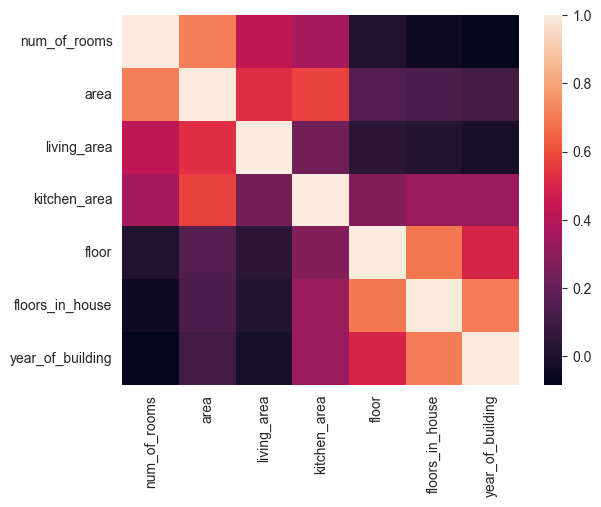

In [6]:
correlation_matrix = X_Kyiv.corr()

sns.heatmap(correlation_matrix)
plt.show()

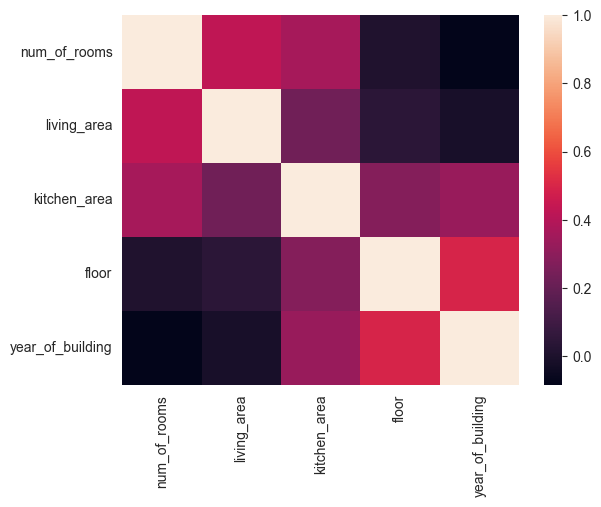

In [7]:
X_Kyiv = X_Kyiv.drop(columns=["area", "floors_in_house"])

correlation_matrix = X_Kyiv.corr()

sns.heatmap(correlation_matrix)
plt.show()

In [8]:
X_Kyiv_new = QuantileTransformer().fit_transform(X_Kyiv)

X_train_Kyiv, X_test_Kyiv, y_train_Kyiv, y_test_Kyiv = train_test_split(X_Kyiv_new, y_Kyiv, test_size=0.2, random_state=42)

In [9]:
grid_random_forest_Kyiv = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid={"n_estimators": [i for i in range(100, 1001, 100)]},
    return_train_score=True,
    n_jobs=-1,
)
grid_random_forest_Kyiv.fit(X_train_Kyiv, y_train_Kyiv)

best_model_forest_Kyiv = grid_random_forest_Kyiv.best_estimator_
y_pred_forest_Kyiv = best_model_forest_Kyiv.predict(X_test_Kyiv)

In [10]:
grid_neighbors_Kyiv = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid={"n_neighbors": [i for i in range(1, 11)]},
    return_train_score=True,
    n_jobs=-1,
)
grid_neighbors_Kyiv.fit(X_train_Kyiv, y_train_Kyiv)

best_model_neighbor_Kyiv = grid_neighbors_Kyiv.best_estimator_
y_pred_neighbor_Kyiv = best_model_neighbor_Kyiv.predict(X_test_Kyiv)

In [11]:
tree_regression_Kyiv = tree.DecisionTreeRegressor()
tree_regression_Kyiv.fit(X_train_Kyiv, y_train_Kyiv)

y_pred_regression_Kyiv = tree_regression_Kyiv.predict(X_test_Kyiv)

In [12]:
from sklearn.linear_model import LinearRegression

linear_regression_Kyiv = LinearRegression()
linear_regression_Kyiv.fit(X_train_Kyiv, y_train_Kyiv)

y_pred_linear_Kyiv = linear_regression_Kyiv.predict(X_test_Kyiv)

In [24]:
def print_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"MAE (Середня помилка): {mae:.2f}")
    print(f"RMSE (Середньоквадратична помилка): {rmse:.2f}")
    print(f"R2 (Коефіцієнт детермінації): {r2:.4f}")
    print("-" * 30)
    return [mae, rmse, r2]

metrics_forest = print_metrics(y_test_Kyiv, y_pred_forest_Kyiv, "Random Forest")
metrics_knn = print_metrics(y_test_Kyiv, y_pred_neighbor_Kyiv, "K-Neighbors")
metrics_tree = print_metrics(y_test_Kyiv, y_pred_regression_Kyiv, "Decision Tree")
metrics_linear = print_metrics(y_test_Kyiv, y_pred_linear_Kyiv, "Linear Regresiion")

results_df = pd.DataFrame({
    "Model": ["Random Forest", "K-Neighbors", "Decision Tree", "Linear Regression"],
    "MAE": [metrics_forest[0], metrics_knn[0], metrics_tree[0], metrics_linear[0]],
    "RMSE": [metrics_forest[1], metrics_knn[1], metrics_tree[1], metrics_linear[1]],
    "R2": [metrics_forest[2], metrics_knn[2], metrics_tree[2], metrics_linear[2]]
})

results_df

--- Random Forest ---
MAE (Середня помилка): 504.34
RMSE (Середньоквадратична помилка): 787.46
R2 (Коефіцієнт детермінації): 0.4457
------------------------------
--- K-Neighbors ---
MAE (Середня помилка): 558.45
RMSE (Середньоквадратична помилка): 885.12
R2 (Коефіцієнт детермінації): 0.2997
------------------------------
--- Decision Tree ---
MAE (Середня помилка): 670.05
RMSE (Середньоквадратична помилка): 1099.58
R2 (Коефіцієнт детермінації): -0.0808
------------------------------
--- Linear Regresiion ---
MAE (Середня помилка): 633.45
RMSE (Середньоквадратична помилка): 954.89
R2 (Коефіцієнт детермінації): 0.1849
------------------------------


,Model,MAE,RMSE,R2
0,Random Forest,504.344778,787.463215,0.445687
1,K-Neighbors,558.451159,885.116546,0.299681
2,Decision Tree,670.051005,1099.584515,-0.080817
3,Linear Regression,633.445335,954.893863,0.184911


C:\Users\tempM\AppData\Local\Temp\ipykernel_12380\4100920166.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")


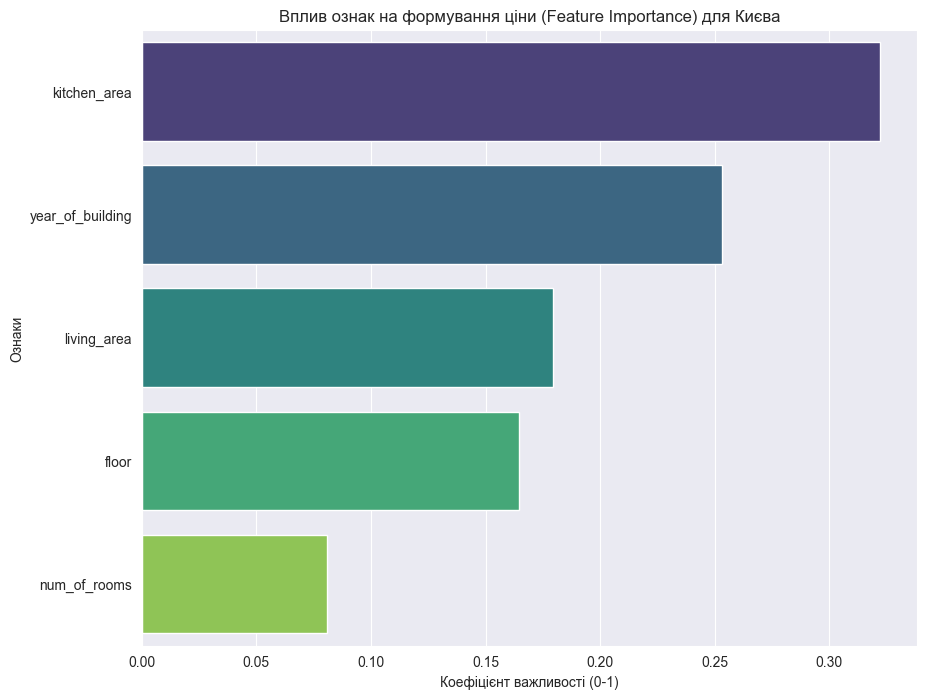

            Feature  Importance
2      kitchen_area    0.322052
4  year_of_building    0.253162
1       living_area    0.179226
3             floor    0.164788
0      num_of_rooms    0.080772


In [14]:
feature_names = X_Kyiv.columns 
importances = best_model_forest_Kyiv.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
plt.title("Вплив ознак на формування ціни (Feature Importance) для Києва")
plt.xlabel("Коефіцієнт важливості (0-1)")
plt.ylabel("Ознаки")
plt.show()

print(feature_importance_df)

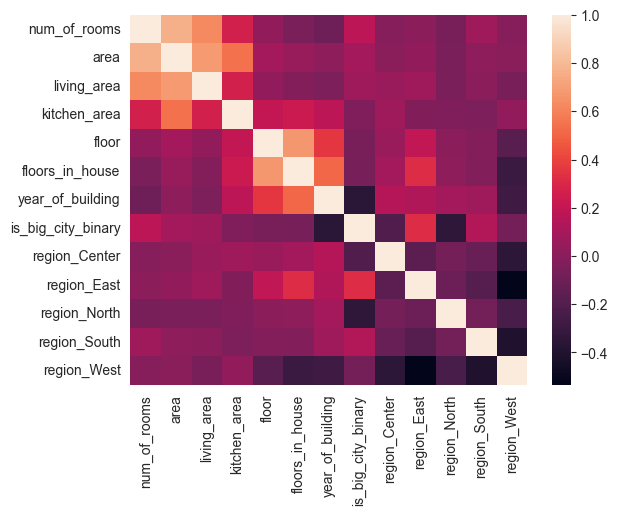

In [15]:
correlation_matrix = X_other.corr()

sns.heatmap(correlation_matrix)
plt.show()

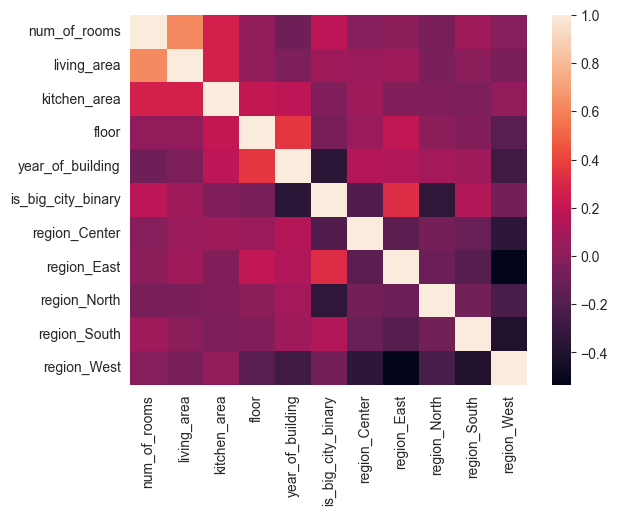

In [16]:
X_other = X_other.drop(columns=["area", "floors_in_house"])

correlation_matrix = X_other.corr()

sns.heatmap(correlation_matrix)
plt.show()

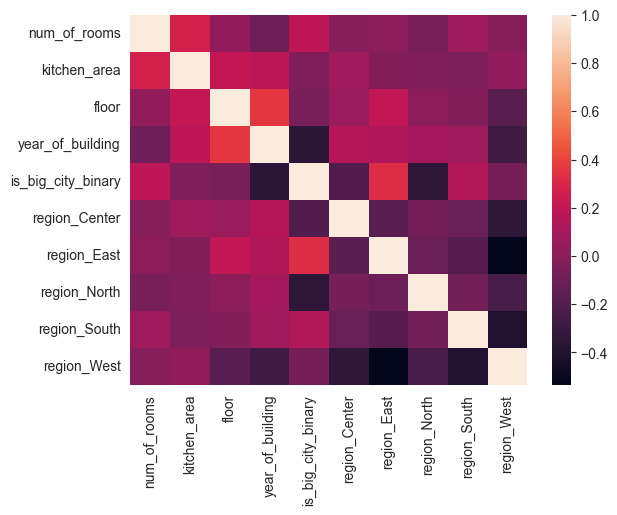

In [17]:
X_other = X_other.drop(columns=["living_area"])

correlation_matrix = X_other.corr()

sns.heatmap(correlation_matrix)
plt.show()

In [18]:
X_new_other = QuantileTransformer().fit_transform(X_other)

X_train_other, X_test_other, y_train_other, y_test_other = train_test_split(X_new_other, y_other, test_size=0.2, random_state=42)

In [19]:
grid_random_forest_other = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid={"n_estimators": [i for i in range(100, 1001, 100)]},
    return_train_score=True,
    n_jobs=-1,
)
grid_random_forest_other.fit(X_train_other, y_train_other)

best_model_forest_other = grid_random_forest_other.best_estimator_
y_pred_forest_other = best_model_forest_other.predict(X_test_other)

In [20]:
grid_neighbors_other = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid={"n_neighbors": [i for i in range(1, 11)]},
    return_train_score=True,
    n_jobs=-1,
)
grid_neighbors_other.fit(X_train_other, y_train_other)

best_model_neighbor_other = grid_neighbors_other.best_estimator_
y_pred_neighbor_other = best_model_neighbor_other.predict(X_test_other)

In [21]:
tree_regression_other = tree.DecisionTreeRegressor()
tree_regression_other.fit(X_train_other, y_train_other)

y_pred_regression_other = tree_regression_other.predict(X_test_other)

In [25]:
linear_regression_other = LinearRegression()
linear_regression_other.fit(X_train_other, y_train_other)

y_pred_linear_other = linear_regression_other.predict(X_test_other)

In [26]:
metrics_forest = print_metrics(y_test_other, y_pred_forest_other, "Random Forest")
metrics_knn = print_metrics(y_test_other, y_pred_neighbor_other, "K-Neighbors")
metrics_tree = print_metrics(y_test_other, y_pred_regression_other, "Decision Tree")
metrics_linear = print_metrics(y_test_other, y_pred_linear_other, "Linear Regression")

results_df = pd.DataFrame({
    "Model": ["Random Forest", "K-Neighbors", "Decision Tree", "Linear Regression"],
    "MAE": [metrics_forest[0], metrics_knn[0], metrics_tree[0], metrics_linear[0]],
    "RMSE": [metrics_forest[1], metrics_knn[1], metrics_tree[1], metrics_linear[1]],
    "R2": [metrics_forest[2], metrics_knn[2], metrics_tree[2], metrics_linear[2]]
})

results_df

--- Random Forest ---
MAE (Середня помилка): 281.45
RMSE (Середньоквадратична помилка): 387.91
R2 (Коефіцієнт детермінації): 0.5270
------------------------------
--- K-Neighbors ---
MAE (Середня помилка): 292.95
RMSE (Середньоквадратична помилка): 411.23
R2 (Коефіцієнт детермінації): 0.4684
------------------------------
--- Decision Tree ---
MAE (Середня помилка): 321.47
RMSE (Середньоквадратична помилка): 449.92
R2 (Коефіцієнт детермінації): 0.3637
------------------------------
--- Linear Regression ---
MAE (Середня помилка): 317.01
RMSE (Середньоквадратична помилка): 429.75
R2 (Коефіцієнт детермінації): 0.4195
------------------------------


,Model,MAE,RMSE,R2
0,Random Forest,281.453543,387.913621,0.526994
1,K-Neighbors,292.948936,411.229033,0.468426
2,Decision Tree,321.472074,449.922685,0.363685
3,Linear Regression,317.005773,429.747095,0.419473


C:\Users\tempM\AppData\Local\Temp\ipykernel_12380\3711597387.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")


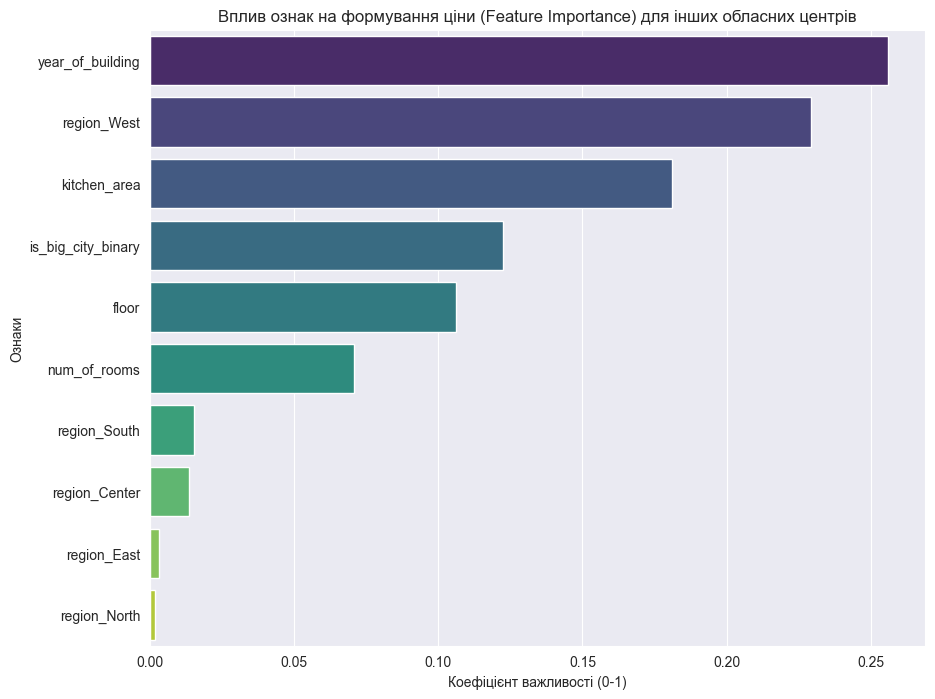

              Feature  Importance
3    year_of_building    0.256057
9         region_West    0.229428
1        kitchen_area    0.181254
4  is_big_city_binary    0.122415
2               floor    0.106289
0        num_of_rooms    0.070752
8        region_South    0.015373
5       region_Center    0.013576
6         region_East    0.003187
7        region_North    0.001669


In [23]:
feature_names = X_other.columns 
importances = best_model_forest_other.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis")
plt.title("Вплив ознак на формування ціни (Feature Importance) для інших обласних центрів")
plt.xlabel("Коефіцієнт важливості (0-1)")
plt.ylabel("Ознаки")
plt.show()

print(feature_importance_df)